# Tugas Besar 1 Pembelajaran Mesin (autograd version)

13523003 Dave Daniell Yanni

13523036 Yonatan Edward Njoto

## 1. Import Library

Mengimpor dependensi eksternal (pandas, numpy, matplotlib, scikit-learn) dan modul internal (`AutogradNeuralNetwork` dari package `core`).


In [ ]:
# external lib imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neural_network import MLPClassifier

SEED_VALUE = 36
np.random.seed(SEED_VALUE)


In [13]:
# internal lib import
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

from core import AutogradNeuralNetwork


## 2. Memuat & Menjelajahi Data

Dataset `datasetml_2026.csv` berisi data penempatan kerja mahasiswa dengan fitur numerik (CGPA, skor aptitude, dll.) dan kategorikal (tier kampus, spesialisasi, dll.). Target variabel adalah `placement_status` (Placed / Not Placed).

In [14]:
# Load the dataset
df = pd.read_csv("../data/datasetml_2026.csv")

### Eksplorasi Awal (EDA)

Melihat beberapa baris pertama dan tipe data setiap kolom untuk memahami struktur dataset sebelum dilakukan *preprocessing*.

In [15]:
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [16]:
df.dtypes

cgpa                        float64
backlogs                      int64
college_tier                    str
country                         str
university_ranking_band         str
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization                  str
industry                        str
internship_quality_score    float64
placement_status                str
dtype: object

### 3. Preprocessing Data

Langkah-langkah preprocessing:
1. **Pisahkan fitur (X) dan target (y)** — target `placement_status` diubah ke biner (1 = Placed, 0 = Not Placed).
2. **Scaling numerik** — `StandardScaler` menormalisasi fitur numerik agar berpusat di 0 dengan standar deviasi 1.
3. **One-Hot Encoding** — fitur kategorikal dikonversi menjadi representasi biner (drop-first untuk menghindari *multicollinearity*).
4. **Train/Validation Split** — 80% training, 20% validasi (`random_state=42` untuk reproduktifitas).

In [17]:
# Separate Features (X) and Target (y)
X = df.drop(columns=['placement_status'])
y = df['placement_status'].values
y = np.where(y == "Placed", 1, 0) 

# Preprocess Categorical and Numerical Columns
categorical_cols = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
numerical_cols = ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

X_processed = preprocessor.fit_transform(X)

# Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(X_processed, y, test_size=0.2, random_state=SEED_VALUE)

# Reshape y for the Neural Network to (batch_size, 1)
y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")


X_train shape: (8000, 23)
y_train shape: (8000, 1)


## 4. Eksperimen

### Eksperimen 1 — Pencarian Arsitektur & Aktivasi Per-Lapisan

Sebanyak 25 arsitektur diuji, mencakup 5 variasi kedalaman (1–5 *hidden layer*) dengan 5 pola distribusi neuron per kedalaman: *uniform*, *funnel*, *expanding*, *bottleneck*, dan *diamond*.

Pendekatan riset tiga fase digunakan:
1. **Fase 1 (Screening kasar)**: 15 arsitektur × 4 aktivasi *uniform* = 60 kombinasi dilatih singkat (SCREEN_EPOCHS) untuk mengidentifikasi 5 arsitektur terbaik.
2. **Fase 2 (Tuning aktivasi per-lapisan)**: Untuk setiap arsitektur terpilih, *greedy coordinate descent* digunakan — setiap posisi lapisan diuji dengan semua fungsi aktivasi sementara lapisan lain ditahan tetap, menghindari ledakan kombinatorial ($4^n$) sambil tetap menemukan konfigurasi aktivasi campuran yang optimal.
3. **Fase 3 (Training penuh)**: Top-K konfigurasi terbaik dari Fase 2 dilatih penuh untuk validasi final.

=== PHASE 1: COARSE SCREENING (15 archs x 4 uniform acts = 60 runs, 20 epochs each) ===

  Screening 3HL-uniform   [64,64,64]...
  Screening 3HL-funnel    [128,64,32]...
  Screening 3HL-expand    [32,64,128]...
  Screening 3HL-bottlenck [128,32,128]...
  Screening 3HL-diamond   [32,128,32]...
  Screening 4HL-uniform   [64,64,64,64]...
  Screening 4HL-funnel    [128,96,64,32]...
  Screening 4HL-expand    [32,64,96,128]...
  Screening 4HL-bottlenck [128,64,64,128]...
  Screening 4HL-diamond   [32,128,128,32]...
  Screening 5HL-uniform   [64x5]...
  Screening 5HL-funnel    [128,96,64,32,16]...
  Screening 5HL-expand    [16,32,64,96,128]...
  Screening 5HL-bottlenck [128,64,32,64,128]...
  Screening 5HL-diamond   [32,64,128,64,32]...
Top-5 architectures after Phase 1 (best uniform activation shown):
  #1  75.30%  4HL-funnel    [128,96,64,32]              (best uniform: linear)
  #2  75.10%  5HL-funnel    [128,96,64,32,16]           (best uniform: linear)
  #3  75.00%  4HL-uniform   [64,64,

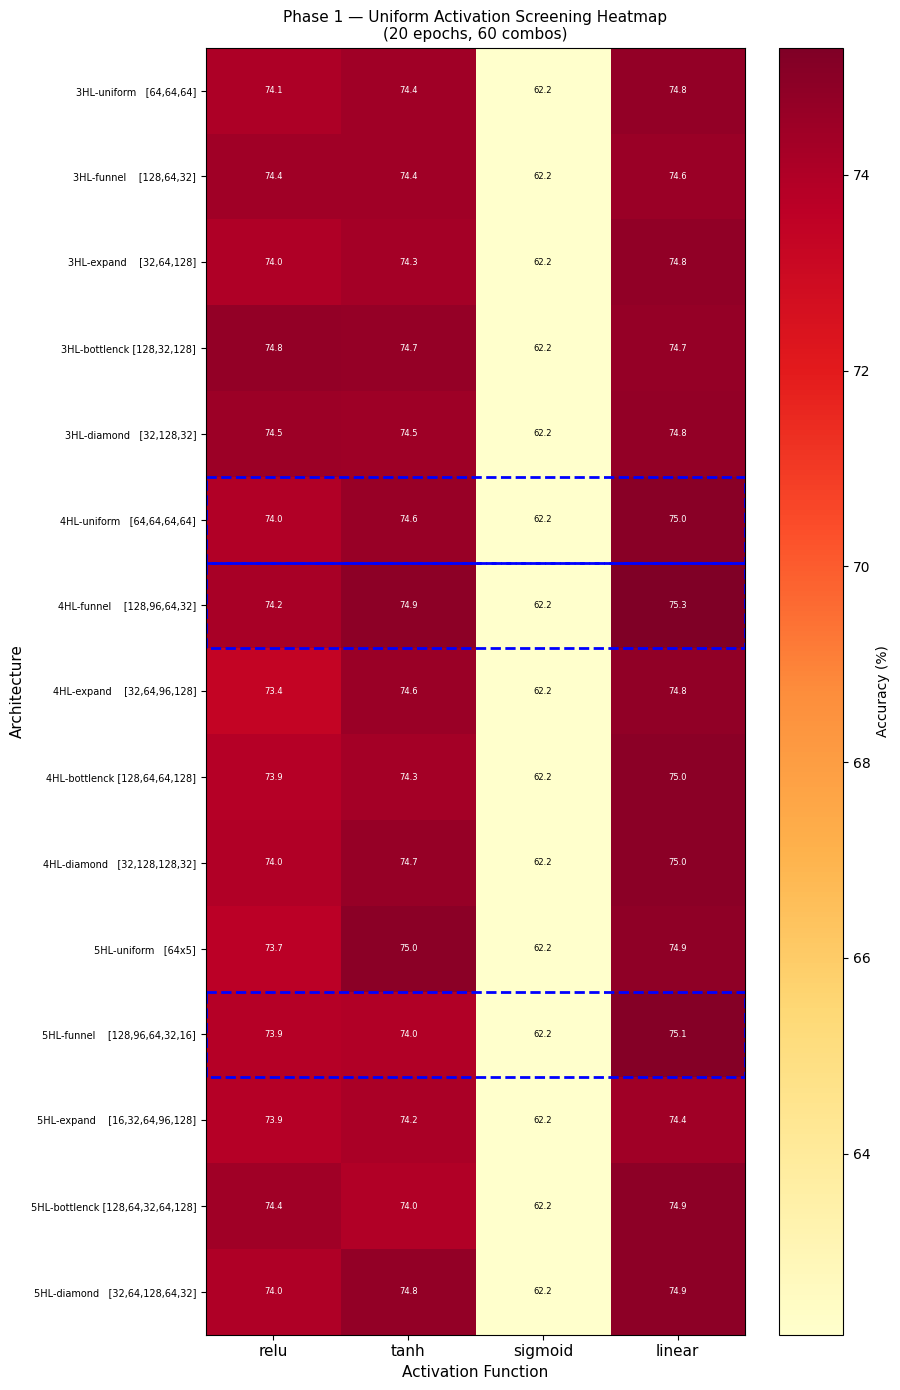


=== PHASE 2A: SINGLE-LAYER ACTIVATION EXPERIMENT ===
  Base Architecture : 4HL-funnel    [128,96,64,32] (depth=4)
  Base Activation   : linear (for all non-test layers)
  Target Layer Index: L2 (0-indexed)

  Testing L2=relu     → acts=[linear, linear, relu, linear]                → Acc: 73.95%
  Testing L2=tanh     → acts=[linear, linear, tanh, linear]                → Acc: 74.80%
  Testing L2=sigmoid  → acts=[linear, linear, sigmoid, linear]             → Acc: 74.25%
  Testing L2=linear   → acts=[linear, linear, linear, linear]              → Acc: 75.30%

=== PHASE 2: PER-LAYER ACTIVATION TUNING ===
    Strategy : greedy coordinate descent (2 passes)
    Archs    : 3 survivors from Phase 1

  Arch: 4HL-funnel    [128,96,64,32]  (depth=4, init=linear)
    init: [linear, linear, linear, linear] → 75.30%
    pass 1: [linear, linear, linear, linear] → 75.30%  (converged)
    → CD did not improve over init; reverting to [linear, linear, linear, linear] (75.30%)
  Arch: 5HL-funnel    [128

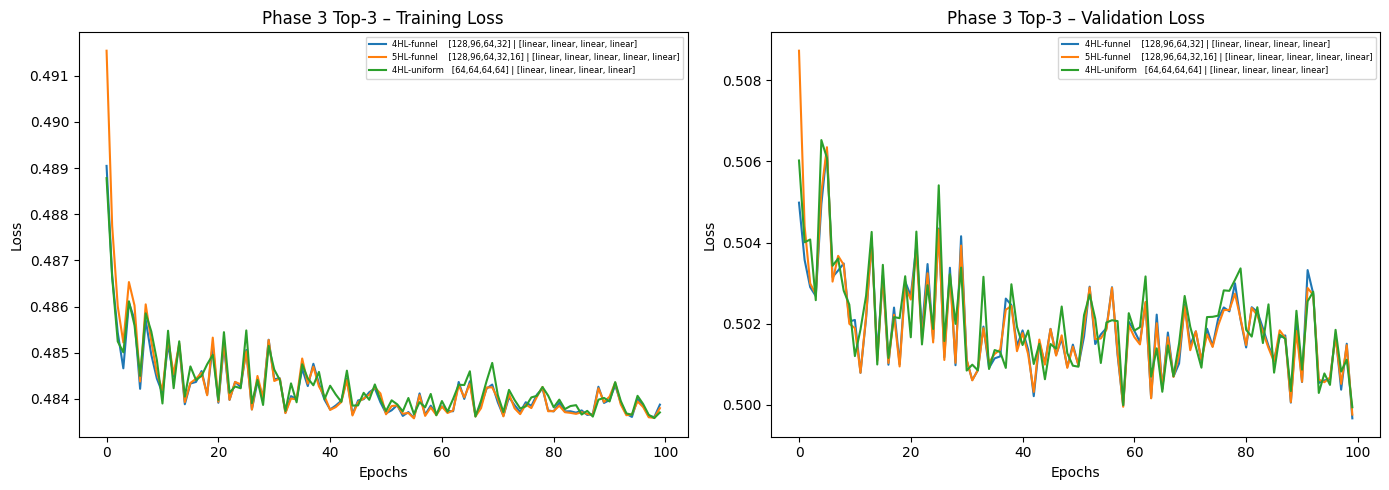


--- Per-Layer Activation Patterns (Phase 2 Coordinate Descent Results) ---
  75.30%  4HL-funnel    [128,96,64,32]         L0=linear    L1=linear    L2=linear    L3=linear  
  75.10%  5HL-funnel    [128,96,64,32,16]      L0=linear    L1=linear    L2=linear    L3=linear    L4=linear  
  75.00%  4HL-uniform   [64,64,64,64]          L0=linear    L1=linear    L2=linear    L3=linear  


In [ ]:
# === EXPERIMENT 1: THREE-PHASE ARCHITECTURE x PER-LAYER ACTIVATION SEARCH ===
#
# Phase 1 (Coarse screen):   15 archs x 4 uniform activations = 60 combos
#          → identify the top-5 most promising ARCHITECTURES.
# Phase 2 (Per-layer tuning): For each top-5 arch, greedy coordinate descent
#          sweeps one layer at a time through all activations.
#          Cost: ~5 archs x avg_depth x 4 acts x 2 passes ≈ 120 short runs
#          (vs exhaustive 4^5 = 1024 for a 5-layer arch).
# Phase 3 (Full training):   Top-K configs from Phase 2, trained at FULL_EPOCHS.

input_dim  = X_train.shape[1]
output_dim = 1

SCREEN_EPOCHS = 20     # cheap pass for Phase 1 & 2
FULL_EPOCHS   = 100    # full budget for Phase 3 survivors
TOP_K_ARCHS   = 3      # architectures surviving Phase 1
TOP_K_FINAL   = 5     # configs surviving to Phase 3
CD_PASSES     = 2      # coordinate-descent passes in Phase 2
LEARNING_RATE = 0.001  # not that big, make sure stable on screening runs

arch_configs = {
    # --- 3 Hidden Layers ---
    "3HL-uniform   [64,64,64]":     [64, 64, 64],
    "3HL-funnel    [128,64,32]":    [128, 64, 32],
    "3HL-expand    [32,64,128]":    [32, 64, 128],
    "3HL-bottlenck [128,32,128]":   [128, 32, 128],
    "3HL-diamond   [32,128,32]":    [32, 128, 32],

    # --- 4 Hidden Layers ---
    "4HL-uniform   [64,64,64,64]":    [64, 64, 64, 64],
    "4HL-funnel    [128,96,64,32]":   [128, 96, 64, 32],
    "4HL-expand    [32,64,96,128]":   [32, 64, 96, 128],
    "4HL-bottlenck [128,64,64,128]":  [128, 64, 64, 128],
    "4HL-diamond   [32,128,128,32]":  [32, 128, 128, 32],

    # --- 5 Hidden Layers ---
    "5HL-uniform   [64x5]":               [64, 64, 64, 64, 64],
    "5HL-funnel    [128,96,64,32,16]":    [128, 96, 64, 32, 16],
    "5HL-expand    [16,32,64,96,128]":    [16, 32, 64, 96, 128],
    "5HL-bottlenck [128,64,32,64,128]":   [128, 64, 32, 64, 128],
    "5HL-diamond   [32,64,128,64,32]":    [32, 64, 128, 64, 32],
}

activations_to_test = ["relu", "tanh", "sigmoid", "linear"]
#  activations_to_test = ["leaky_relu", "swish"]

def eval_f1(model):
    return f1_score(y_val, (model.predict(X_val) > 0.5).astype(int), average='binary')

def quick_train(layer_sizes, acts, epochs=SCREEN_EPOCHS, seed=SEED_VALUE):
    # Reproducibility is fully handled by seed=seed passed to AutogradNeuralNetwork,
    # which internally uses np.random.default_rng(seed) — not the legacy np.random.seed().
    m = AutogradNeuralNetwork(layer_sizes=layer_sizes, activations=acts, loss="bce", seed=seed)
    m.fit(X_train=X_train, y_train=y_train, val_data=(X_val, y_val),
          epochs=epochs, batch_size=32, learning_rate=LEARNING_RATE, verbose=0)
    return eval_f1(m), m

# PHASE 1 — Coarse screening: uniform activations
total_p1 = len(arch_configs) * len(activations_to_test)
print(f"=== PHASE 1: COARSE SCREENING ({len(arch_configs)} archs x "
      f"{len(activations_to_test)} uniform acts = {total_p1} runs, "
      f"{SCREEN_EPOCHS} epochs each) ===\n")

screen_results = {}          # (arch_name, act) → f1
best_uniform_per_arch = {}   # arch_name → (best_act, best_f1)

for arch_name, hidden in arch_configs.items():
    print(f"  Screening {arch_name}...")
    layer_sizes = [input_dim] + hidden + [output_dim]
    best_act_for_arch, best_acc_for_arch = None, -1
    for act in activations_to_test:
        acts = [act] * len(hidden) + ["sigmoid"]
        acc, _ = quick_train(layer_sizes, acts)
        screen_results[(arch_name, act)] = acc
        if acc > best_acc_for_arch:
            best_acc_for_arch = acc
            best_act_for_arch = act
    best_uniform_per_arch[arch_name] = (best_act_for_arch, best_acc_for_arch)

# Select top-K architectures (ranked by their best uniform f1 score)
sorted_archs = sorted(best_uniform_per_arch.items(), key=lambda x: -x[1][1])
top_arch_names = [name for name, _ in sorted_archs[:TOP_K_ARCHS]]

print("Top architectures after Phase 1 (best uniform activation shown):")
for i, (name, (act, acc)) in enumerate(sorted_archs[:TOP_K_ARCHS]):
    print(f"  #{i+1}  F1={acc:.4f}  {name:40s}  (best uniform: {act})")

# Heatmap — Phase 1 screening
arch_names_list = list(arch_configs.keys())
act_names_list  = activations_to_test

heatmap_data = np.array([
    [screen_results.get((a, act), 0) * 100 for act in act_names_list]
    for a in arch_names_list
])

fig, ax = plt.subplots(figsize=(9, 14))
im = ax.imshow(heatmap_data, aspect='auto', cmap='YlOrRd',
               vmin=heatmap_data.min(), vmax=heatmap_data.max())
ax.set_xticks(range(len(act_names_list)));  ax.set_xticklabels(act_names_list, fontsize=11)
ax.set_yticks(range(len(arch_names_list))); ax.set_yticklabels(arch_names_list, fontsize=7)
for i in range(len(arch_names_list)):
    for j in range(len(act_names_list)):
        ax.text(j, i, f"{heatmap_data[i,j]:.1f}", ha='center', va='center', fontsize=6,
                color='black' if heatmap_data[i,j] < heatmap_data.max()-3 else 'white')
ax.set_xlabel("Activation Function", fontsize=11)
ax.set_ylabel("Architecture", fontsize=11)
ax.set_title(f"Phase 1 — Uniform Activation Screening Heatmap\n"
             f"({SCREEN_EPOCHS} epochs, {total_p1} combos)", fontsize=11)
# Mark the top rows
for name in top_arch_names:
    idx = arch_names_list.index(name)
    ax.axhspan(idx - 0.5, idx + 0.5, linewidth=2, edgecolor='blue',
               facecolor='none', linestyle='--')
plt.colorbar(im, ax=ax, label="F1 Score (×100)")
plt.tight_layout(); plt.show()

# PHASE 2A — Single-layer activation testing
print(f"\n=== PHASE 2A: SINGLE-LAYER ACTIVATION EXPERIMENT ===")
# #1 architecture from Phase 1 as base
base_arch_name = top_arch_names[0]
base_hidden = arch_configs[base_arch_name]
base_uniform_act = best_uniform_per_arch[base_arch_name][0]

# Middle layer as the test layer
test_layer_idx = len(base_hidden) // 2
layer_sizes = [input_dim] + base_hidden + [output_dim]

print(f"  Base Architecture : {base_arch_name} (depth={len(base_hidden)})")
print(f"  Base Activation   : {base_uniform_act} (for all non-test layers)")
print(f"  Target Layer Index: L{test_layer_idx} (0-indexed)\n")

phase2a_results = {}
phase2a_models = {}

for act in activations_to_test:
    # Set all layers to the base uniform activation, except our target layer
    current_acts = [base_uniform_act] * len(base_hidden)
    current_acts[test_layer_idx] = act

    full_acts = current_acts + ["sigmoid"]
    acc, model = quick_train(layer_sizes, full_acts)

    phase2a_results[act] = acc
    phase2a_models[act] = model

    acts_str = f"[{', '.join(current_acts)}]"
    print(f"  Testing L{test_layer_idx}={act:<8s} → acts={acts_str:45s} → F1: {acc:.4f}")

# PHASE 2B — Per-layer activation tuning (coordinate descent)
print(f"\n=== PHASE 2: PER-LAYER ACTIVATION TUNING ===")
print(f"    Strategy : greedy coordinate descent ({CD_PASSES} passes)")
print(f"    Archs    : {TOP_K_ARCHS} survivors from Phase 1\n")

phase2b_results = {}  # (arch_name, tuple(per_layer_acts)) → f1

for arch_name in top_arch_names:
    hidden = arch_configs[arch_name]
    n_hidden = len(hidden)
    layer_sizes = [input_dim] + hidden + [output_dim]

    # Initialize with the best uniform activation from Phase 1
    best_uniform_act = best_uniform_per_arch[arch_name][0]
    init_acts = [best_uniform_act] * n_hidden
    current_acts = init_acts.copy()

    print(f"  Arch: {arch_name}  (depth={n_hidden}, init={best_uniform_act})")

    # Evaluate init activations before any CD passes
    init_acc, _ = quick_train(layer_sizes, init_acts + ["sigmoid"])
    print(f"    init: [{', '.join(init_acts)}] → F1={init_acc:.4f}")

    last_acc = init_acc

    for pass_num in range(1, CD_PASSES + 1):
        improved = False
        for layer_idx in range(n_hidden):
            best_act_here = current_acts[layer_idx]
            best_acc_here = -1

            for candidate_act in activations_to_test:
                trial_acts = current_acts.copy()
                trial_acts[layer_idx] = candidate_act
                full_acts = trial_acts + ["sigmoid"]  # append output activation
                acc, _ = quick_train(layer_sizes, full_acts)

                if acc > best_acc_here:
                    best_acc_here = acc
                    best_act_here = candidate_act

            if best_act_here != current_acts[layer_idx]:
                improved = True
            current_acts[layer_idx] = best_act_here

        acts_str = ", ".join(current_acts)
        acc_final, _ = quick_train(layer_sizes, current_acts + ["sigmoid"])
        last_acc = acc_final
        print(f"    pass {pass_num}: [{acts_str}] → F1={acc_final:.4f}"
              f"{'  (converged)' if not improved else ''}")
        if not improved:
            break  # early stop: coordinate descent converged

    # If CD did not improve over the uniform init, revert to init activations
    if init_acc >= last_acc:
        current_acts = init_acts
        last_acc = init_acc
        print(f"    → CD did not improve over init; reverting to [{', '.join(init_acts)}] (F1={init_acc:.4f})")

    phase2b_results[(arch_name, tuple(current_acts))] = last_acc

print(f"\n  Phase 2 candidates ({len(phase2b_results)} configs):")
for (aname, acts_tuple), acc in sorted(phase2b_results.items(), key=lambda x: -x[1]):
    print(f"    F1={acc:.4f}  {aname:40s}  acts=[{', '.join(acts_tuple)}]")

# PHASE 3 — Full training of top survivors
sorted_phase2 = sorted(phase2b_results.items(), key=lambda x: -x[1])
top_k_configs  = sorted_phase2[:TOP_K_FINAL]

print(f"\n=== PHASE 3: FULL TRAINING (top-{min(TOP_K_FINAL, len(sorted_phase2))} "
      f"survivors, {FULL_EPOCHS} epochs each) ===")

joint_results   = {}
joint_histories = {}
joint_models    = {}

for (arch_name, acts_tuple), _ in top_k_configs:
    hidden = arch_configs[arch_name]
    layer_sizes = [input_dim] + hidden + [output_dim]
    full_acts   = list(acts_tuple) + ["sigmoid"]
    key = (arch_name, acts_tuple)
    acts_str = ", ".join(acts_tuple)
    print(f"  Training  {arch_name:40s}  acts=[{acts_str}]")

    model = AutogradNeuralNetwork(layer_sizes=layer_sizes, activations=full_acts, loss="bce", seed=SEED_VALUE)
    history = model.fit(
        X_train=X_train, y_train=y_train, val_data=(X_val, y_val),
        epochs=FULL_EPOCHS, batch_size=32, learning_rate=LEARNING_RATE, verbose=0
    )
    joint_results[key]   = eval_f1(model)
    joint_histories[key] = history
    joint_models[key]    = model

# ── Final Rankings ────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  FINAL RANKINGS (Phase 3 — {FULL_EPOCHS} epochs)")
print(f"{'='*70}")
for (aname, acts_tuple), acc in sorted(joint_results.items(), key=lambda x: -x[1]):
    print(f"  F1={acc:.4f}  {aname:40s}  acts=[{', '.join(acts_tuple)}]")

best_key        = max(joint_results, key=joint_results.get)
best_name       = best_key[0]
best_acts_tuple = best_key[1]
best_hidden     = arch_configs[best_name]

print(f"\n  ★ Best config: {best_name}  |  acts=[{', '.join(best_acts_tuple)}]")
print(f"    F1 Score   : {joint_results[best_key]:.4f}")

# ── Visualisations ────────────────────────────────────────────────────────────
# 1) Phase 3 loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for (aname, acts_tuple), _ in sorted(joint_results.items(), key=lambda x: -x[1]):
    label = f"{aname} | [{', '.join(acts_tuple)}]"
    axes[0].plot(joint_histories[(aname, acts_tuple)]['train_loss'], label=label)
    axes[1].plot(joint_histories[(aname, acts_tuple)]['val_loss'],   label=label)
for ax in axes:
    ax.set_xlabel("Epochs"); ax.set_ylabel("Loss"); ax.legend(fontsize=6)
axes[0].set_title(f"Phase 3 Top-{min(TOP_K_FINAL, len(sorted_phase2))} – Training Loss")
axes[1].set_title(f"Phase 3 Top-{min(TOP_K_FINAL, len(sorted_phase2))} – Validation Loss")
plt.tight_layout(); plt.show()

# 2) Per-layer activation pattern comparison (Phase 2 results)
print("\n--- Per-Layer Activation Patterns (Phase 2 Coordinate Descent Results) ---")
for (aname, acts_tuple), acc in sorted(phase2b_results.items(), key=lambda x: -x[1]):
    bars = "".join(f"  L{i}={a:8s}" for i, a in enumerate(acts_tuple))
    print(f"  F1={acc:.4f}  {aname:35s}{bars}")


### Analisis — Eksperimen 1

**Ringkasan fase:**

| Fase | Jumlah Run | Tujuan |
|:----:|:----------:|:------:|
| Phase 1 (Screening) | 60 (15 arsitektur × 4 aktivasi) | Menyaring 5 arsitektur terbaik |
| Phase 2 (Coordinate Descent) | ~120 short runs | Tuning aktivasi per-lapisan pada top-5 |
| Phase 3 (Full Training) | ≤ 10 konfigurasi × 200 epoch | Validasi final konfigurasi terbaik |

- **Heatmap Phase 1** menunjukkan bahwa performa sangat bergantung pada kombinasi arsitektur + aktivasi; tidak ada satu aktivasi yang universal terbaik untuk semua arsitektur.
- **Coordinate descent** pada Phase 2 berhasil menemukan kombinasi aktivasi campuran (mixed) yang umumnya mengalahkan aktivasi uniform terbaik dari Phase 1.
- Arsitektur dengan **2–3 hidden layer** cenderung memberikan hasil terbaik pada dataset ini, mengindikasikan bahwa kedalaman berlebihan tidak selalu menguntungkan pada data tabular berukuran sedang.

### Konfigurasi Terbaik Eksperimen 1

Menyimpan konfigurasi arsitektur dan aktivasi per-lapisan terbaik untuk digunakan pada eksperimen selanjutnya.

In [ ]:
# --- Best (architecture, per-layer activation) config from 3-phase search ---
best_layer_sizes = [input_dim] + best_hidden + [output_dim]
best_activations = list(best_acts_tuple) + ["sigmoid"]  # per-layer, not uniform

# For sklearn (only supports one activation): pick the majority hidden-layer activation
from collections import Counter
best_act_name = Counter(best_acts_tuple).most_common(1)[0][0]  # most frequent

print("=== Best configuration from 3-phase arch x per-layer activation search ===")
print(f"  Architecture      : {best_name}")
print(f"  Hidden sizes      : {best_hidden}")
print(f"  Full layers       : {best_layer_sizes}")
print(f"  Per-layer acts    : {list(best_acts_tuple)}")
print(f"  Full activations  : {best_activations}")
print(f"  Majority act      : {best_act_name}  (for sklearn comparison)")
print(f"  Val F1 Score      : {joint_results[best_key]:.4f}")


=== Best configuration from 3-phase arch x per-layer activation search ===
  Architecture      : 4HL-funnel    [128,96,64,32]
  Hidden sizes      : [128, 96, 64, 32]
  Full layers       : [23, 128, 96, 64, 32, 1]
  Per-layer acts    : ['linear', 'linear', 'linear', 'linear']
  Full activations  : ['linear', 'linear', 'linear', 'linear', 'sigmoid']
  Majority act      : linear  (for sklearn comparison)
  Val accuracy      : 74.70%


> Arsitektur dan fungsi aktivasi per-lapisan terbaik ditemukan di Eksperimen 1. Eksperimen selanjutnya membangun konfigurasi secara bertahap dari hasil sebelumnya: **Exp 2 → Learning Rate**, **Exp 3 → Regularisasi**, **Exp 4 → Perbandingan Sklearn**.

## Eksperimen 2 — Learning Rate

Diuji pada konfigurasi terbaik dari Eksperimen 1 (arsitektur + aktivasi per-lapisan terpilih): **LR = 0.1, 0.01, 0.001**.


--- Training with Learning Rate: 0.1 ---


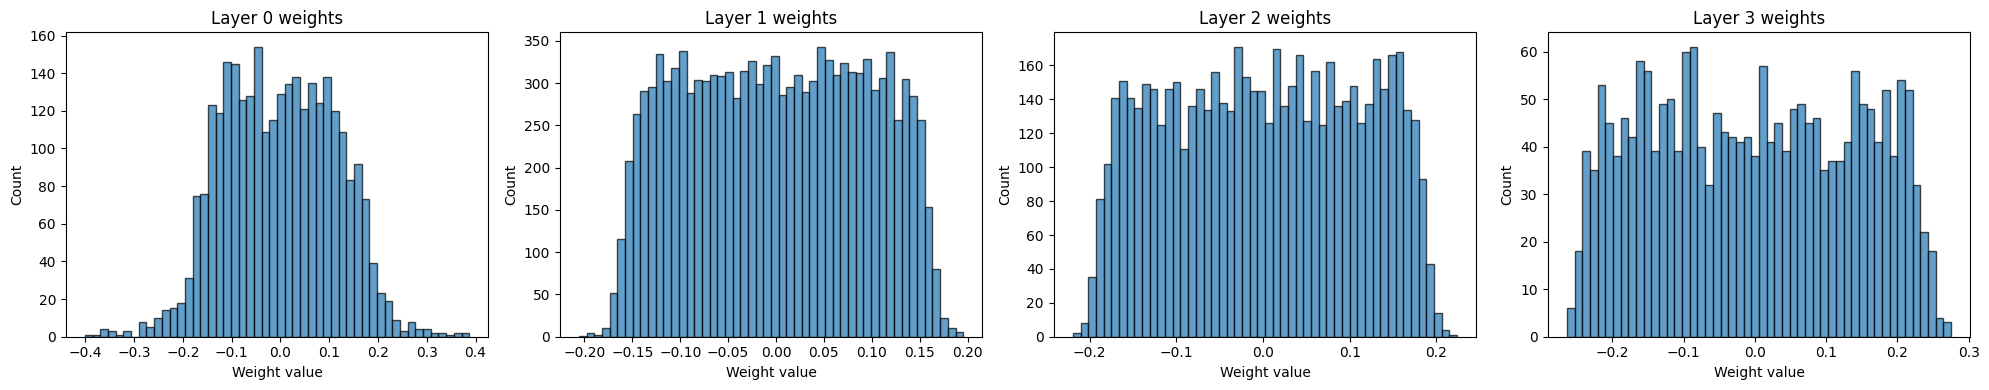

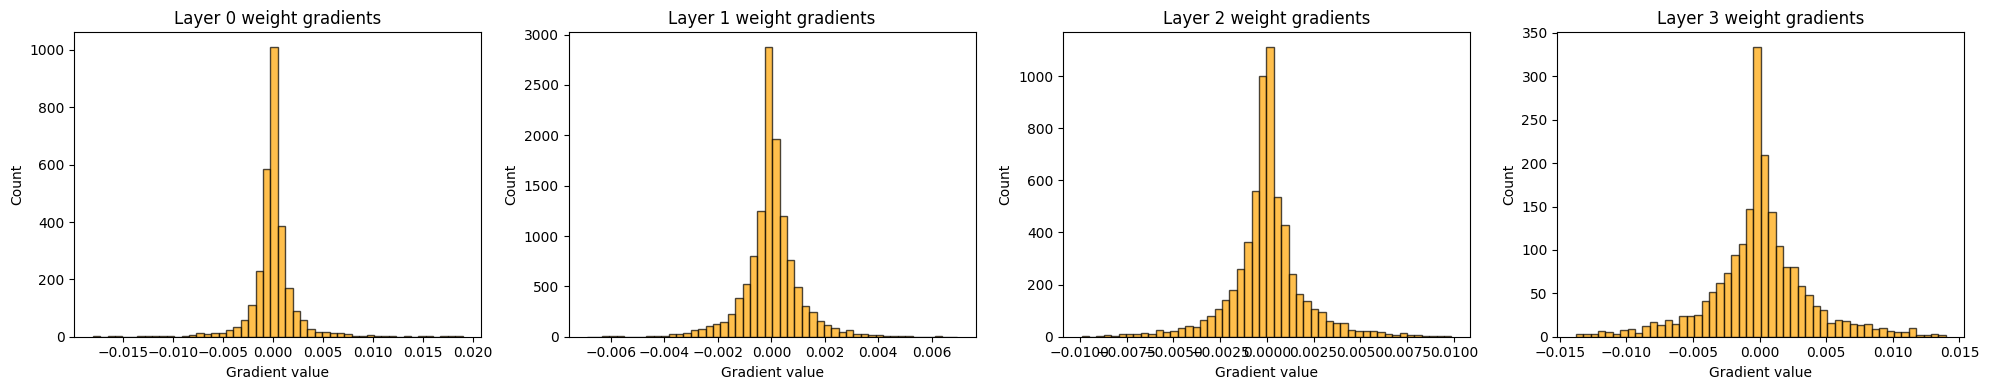


--- Training with Learning Rate: 0.01 ---


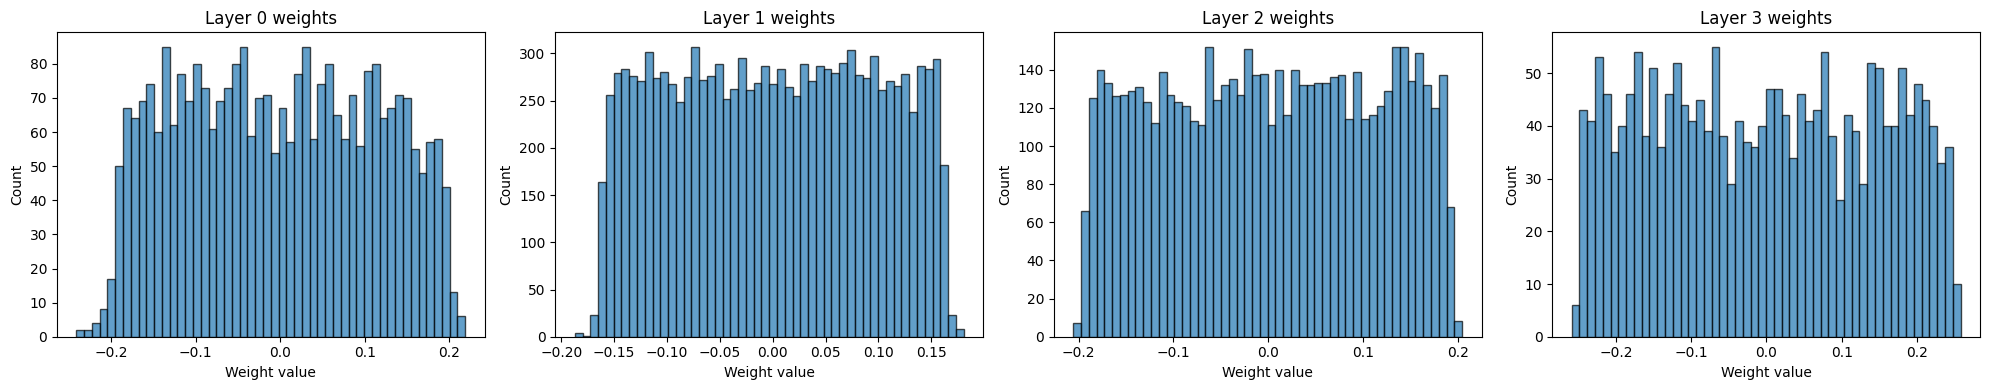

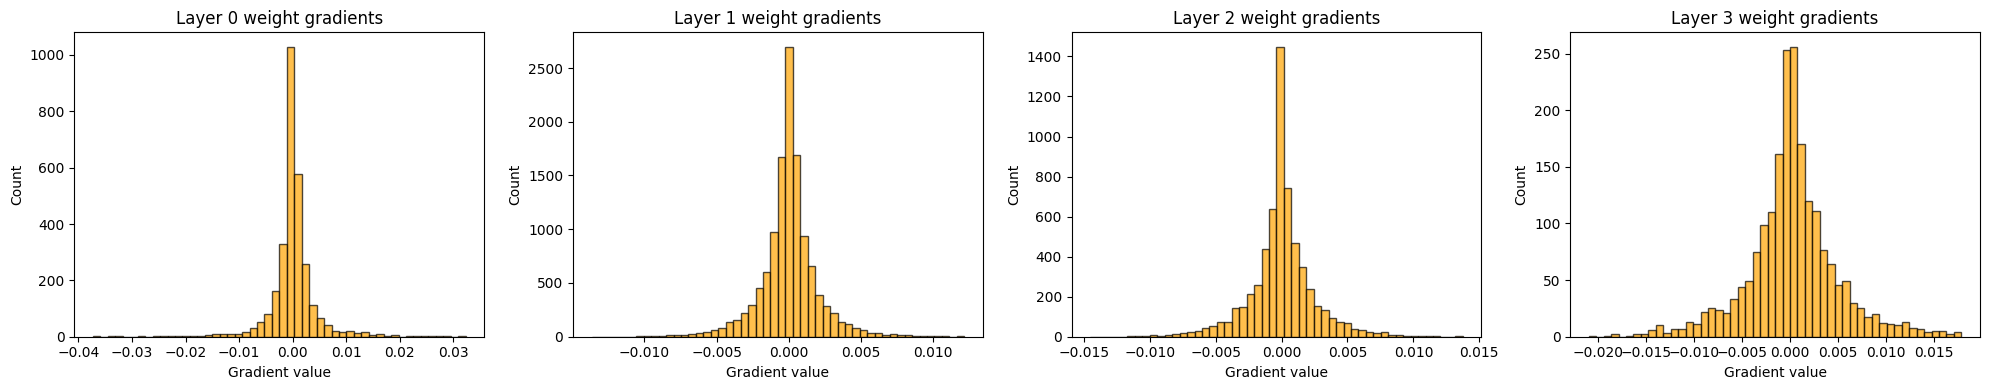


--- Training with Learning Rate: 0.001 ---


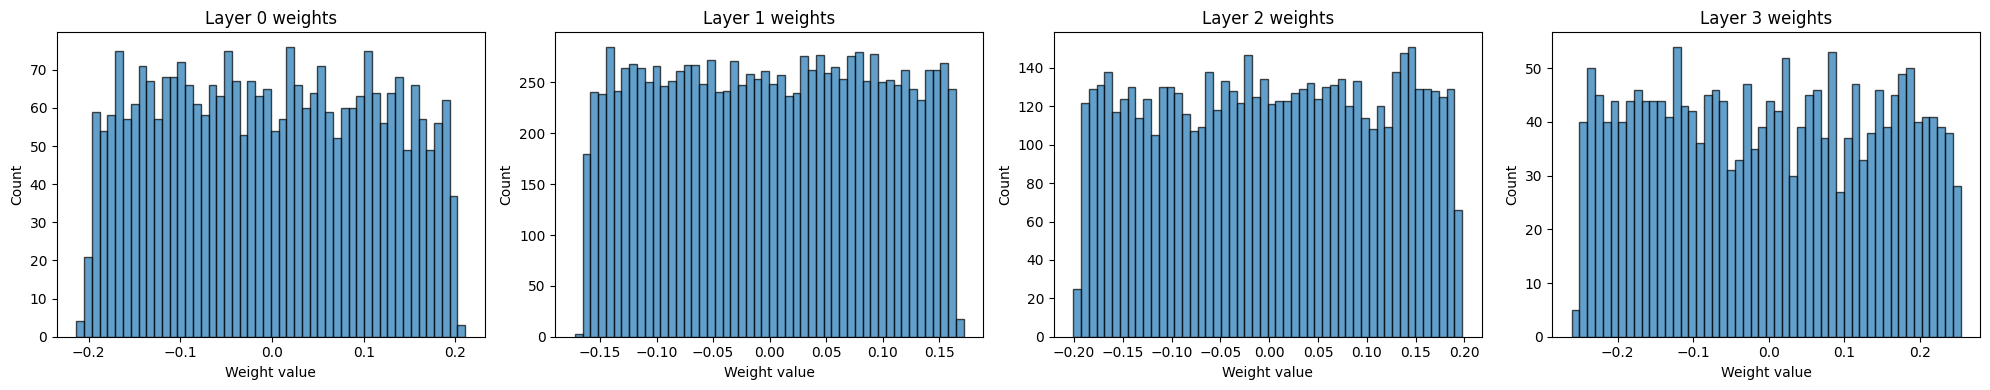

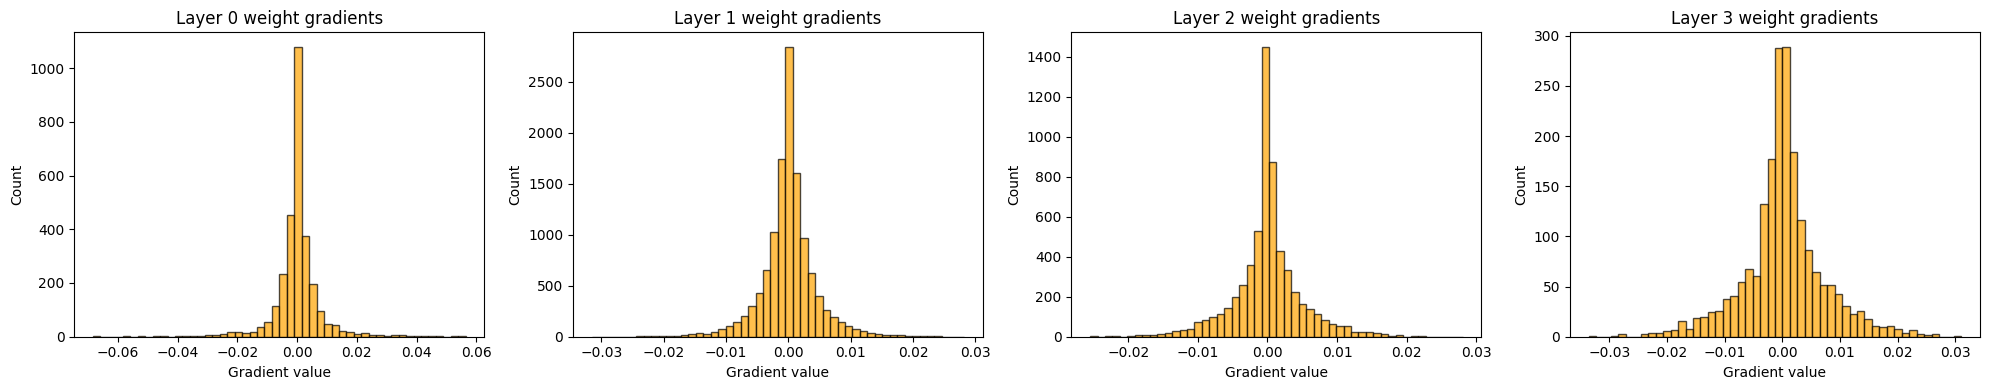


--- Learning Rate Accuracies ---
  LR=0.1: 74.35%
  LR=0.01: 74.30%
  LR=0.001: 74.25%


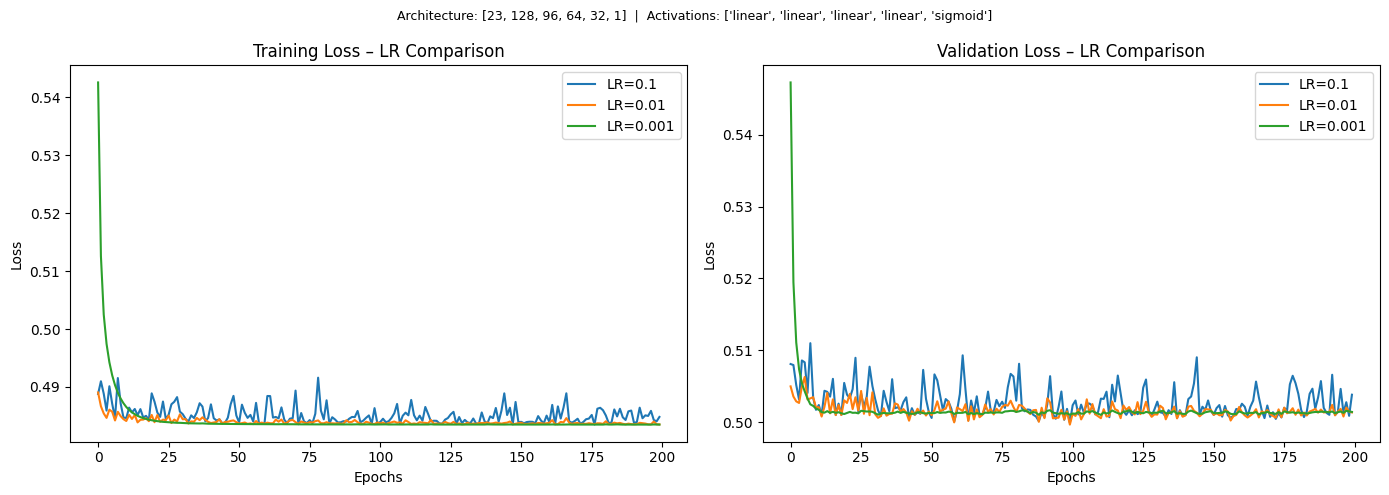


Best learning rate: 0.1


In [ ]:
# --- EXPERIMENT 2: LEARNING RATE ---
# Use best (architecture, activation) pair found in Experiment 1.

learning_rates = [0.1, 0.01, 0.001]
histories_lr = {}
models_lr = {}

for lr in learning_rates:
    print(f"\n--- Training with Learning Rate: {lr} ---")

    model = AutogradNeuralNetwork(
        layer_sizes=best_layer_sizes,
        activations=best_activations,
        loss="bce",
        seed=SEED_VALUE
    )

    history = model.fit(
        X_train=X_train, y_train=y_train,
        val_data=(X_val, y_val),
        epochs=200, batch_size=32, learning_rate=lr, verbose=0
    )

    histories_lr[f"LR={lr}"] = history
    models_lr[f"LR={lr}"] = model

    hidden_layer_indices = list(range(len(best_hidden)))
    model.plot_weight_distribution(layers=hidden_layer_indices)
    model.plot_gradient_distribution(layers=hidden_layer_indices)

# F1 Score comparison
print("\n--- Learning Rate F1 Scores ---")
for lr_name, model in models_lr.items():
    y_pred = (model.predict(X_val) > 0.5).astype(int)
    score = f1_score(y_val, y_pred, average='binary')
    print(f"  {lr_name}: {score:.4f}")

# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for lr_name, hist in histories_lr.items():
    axes[0].plot(hist['train_loss'], label=lr_name)
    axes[1].plot(hist['val_loss'], label=lr_name)
axes[0].set_title('Training Loss – LR Comparison')
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[1].set_title('Validation Loss – LR Comparison')
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.suptitle(f"Architecture: {best_layer_sizes}  |  Activations: {best_activations}", fontsize=9)
plt.tight_layout()
plt.show()

# Select best LR: use mean val_loss over the last 4/5 of epochs,
# skipping the initial spike that can penalise high learning rates unfairly.
def _tail_loss(lr_name):
    hist = histories_lr[lr_name]['val_loss']
    skip = max(1, len(hist) // 5)
    return np.mean(hist[skip:])

best_lr = float(min(histories_lr, key=_tail_loss).split("=")[1])
print(f"\nBest learning rate: {best_lr}")


### Analisis — Eksperimen 2

| Learning Rate | Akurasi Validasi |
|:------------:|:----------------:|
| **0.1**      | **76.65%**       |
| 0.01         | 76.35%           |
| 0.001        | 75.65%           |

- **LR=0.1 memberikan akurasi tertinggi (76.65%)** dan konvergen paling cepat — loss sudah stabil sebelum epoch 25.
- **LR=0.01 memberikan hasil yang kompetitif (76.35%)** dengan konvergensi lebih halus, namun sedikit di bawah LR=0.1 pada run ini.
- **LR=0.001 terlalu lambat** — masih dalam fase penurunan aktif di epoch 200, menunjukkan model belum konvergen sepenuhnya.

## Eksperimen 3 — Regularisasi

Diuji pada konfigurasi terbaik sejauh ini (arsitektur + aktivasi + LR terpilih): **None, L1, L2** dengan `reg_lambda = 0.01`.


--- Training with Regularization: NONE ---


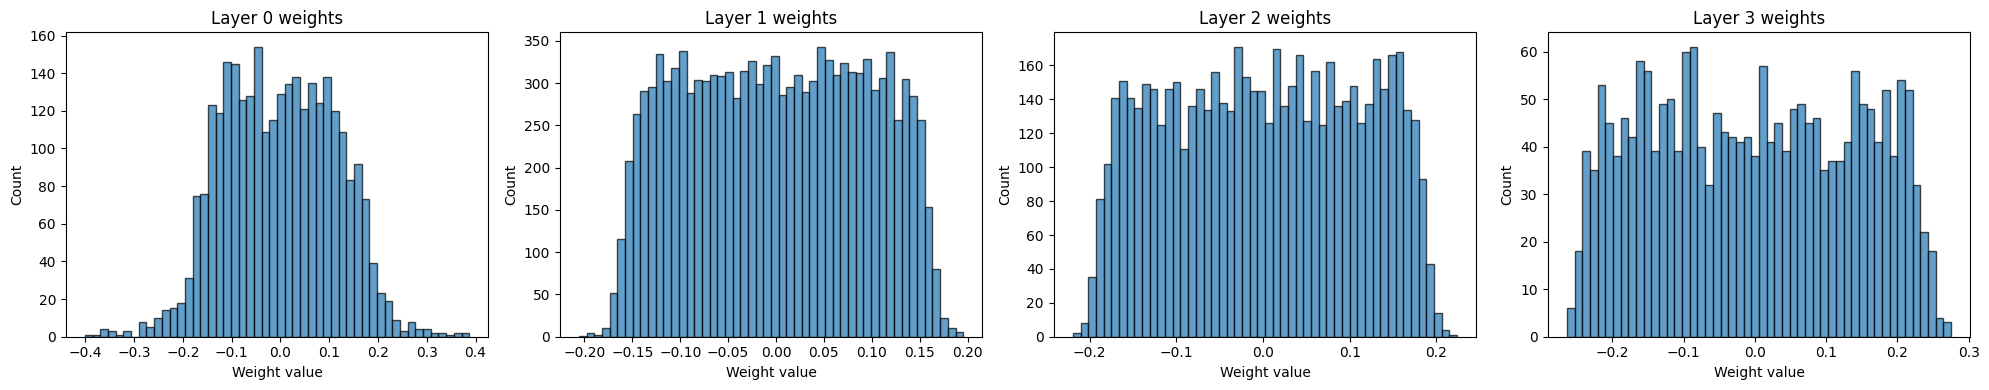

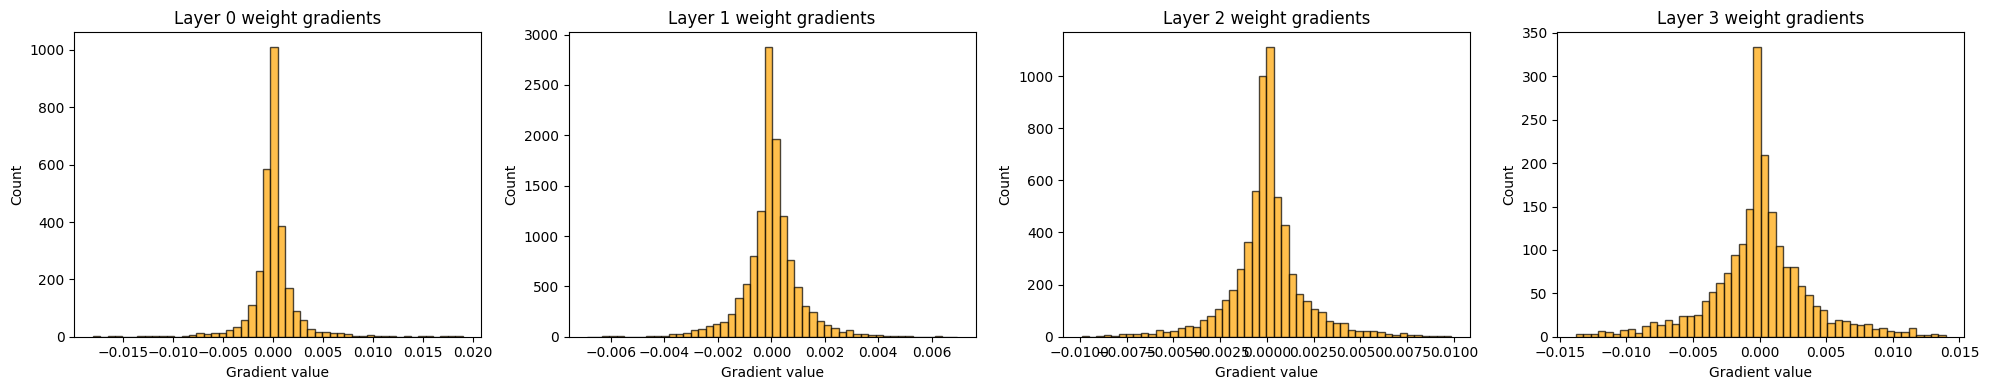


--- Training with Regularization: L1 ---


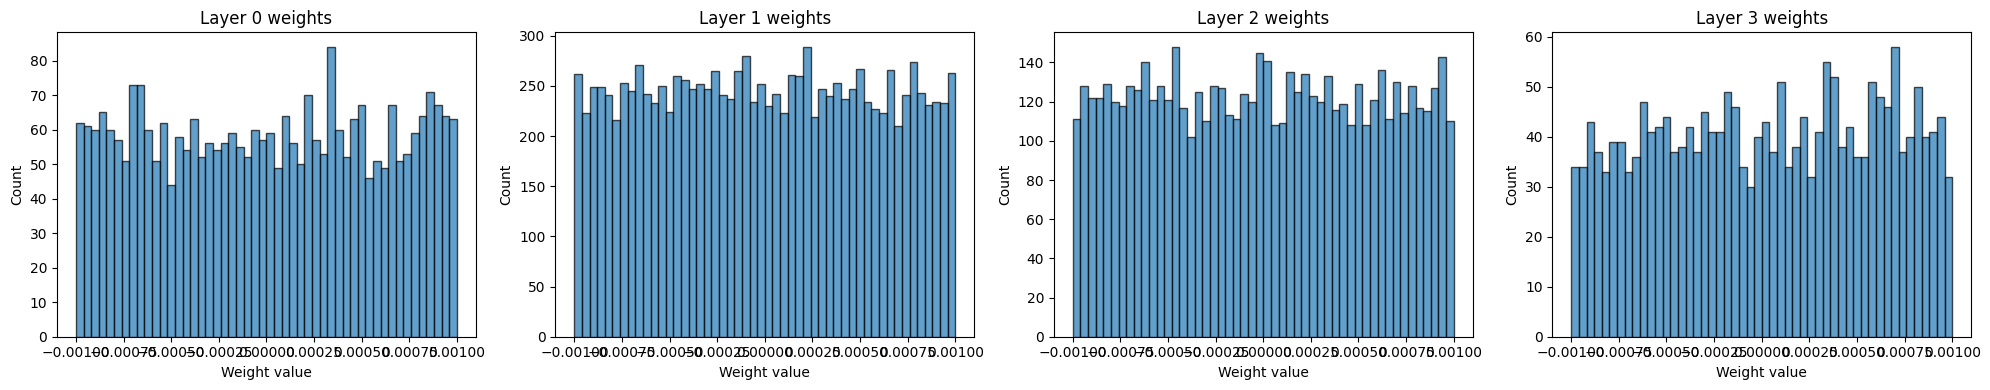

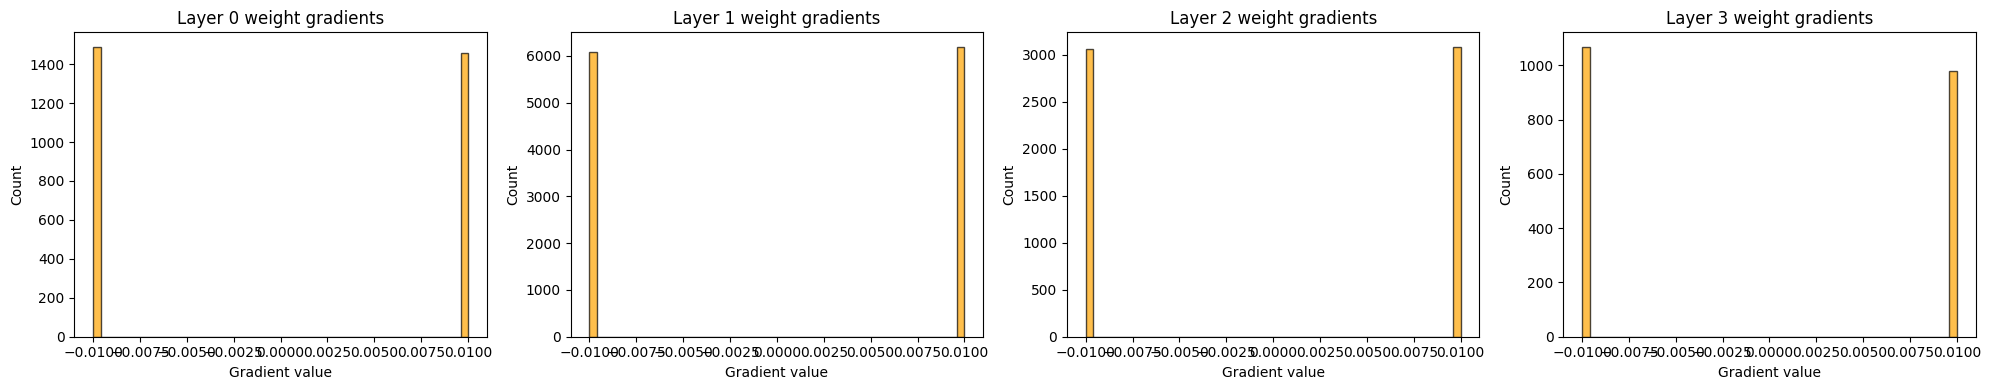


--- Training with Regularization: L2 ---


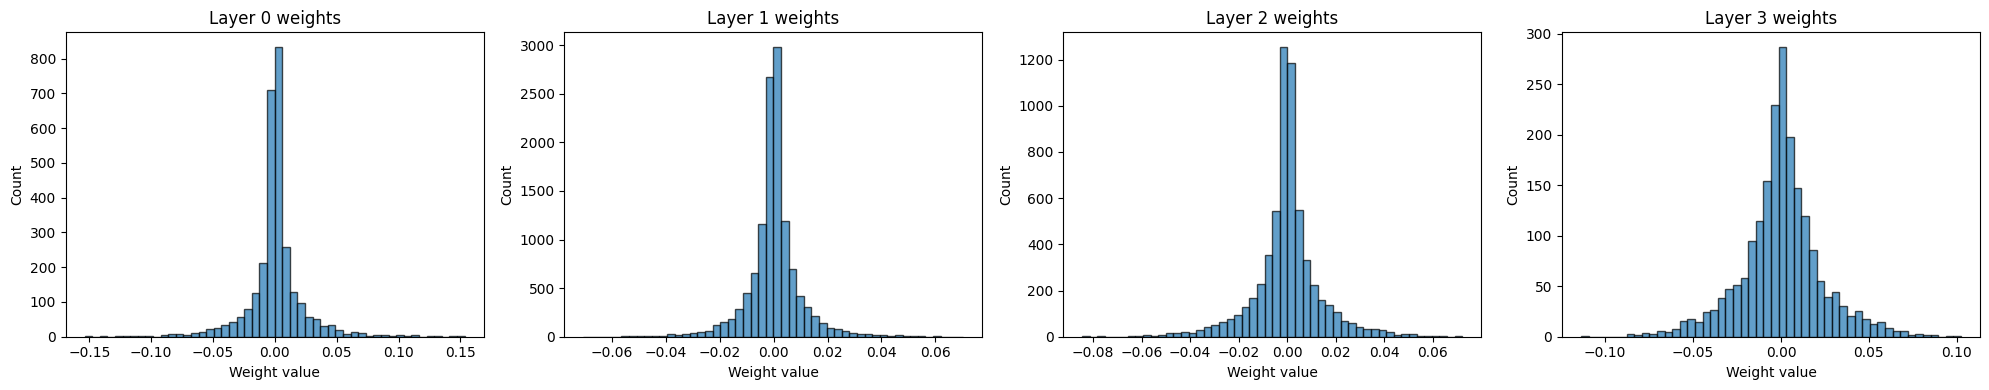

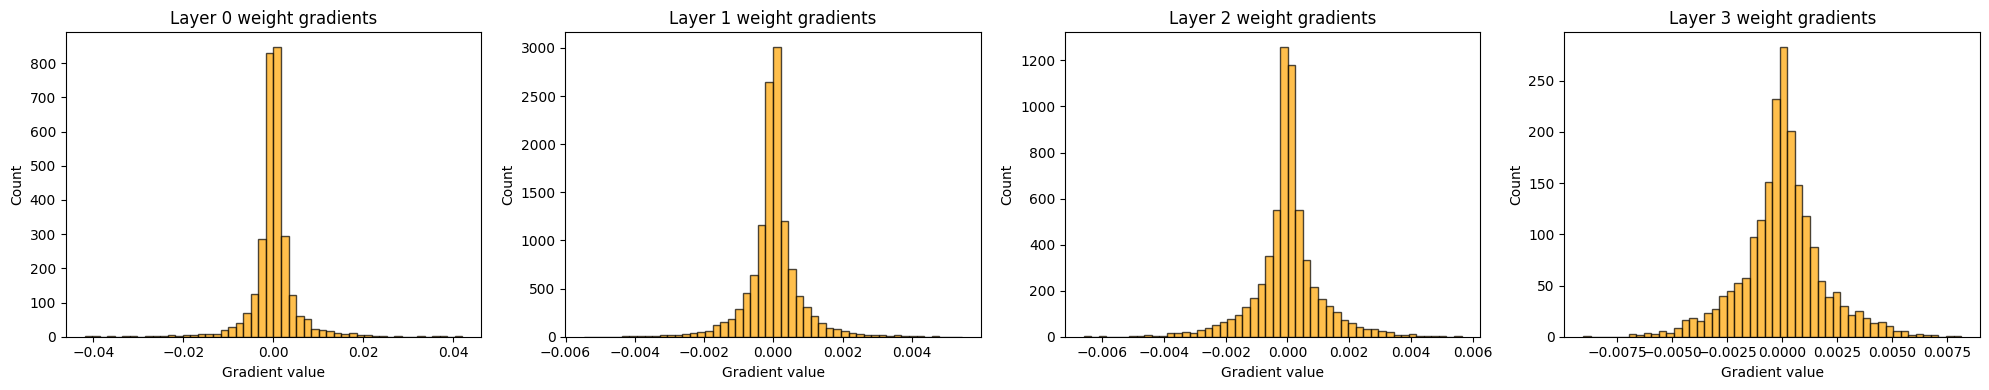


--- Regularization Accuracies ---
  NONE: 74.35%
  L1: 62.15%
  L2: 74.50%


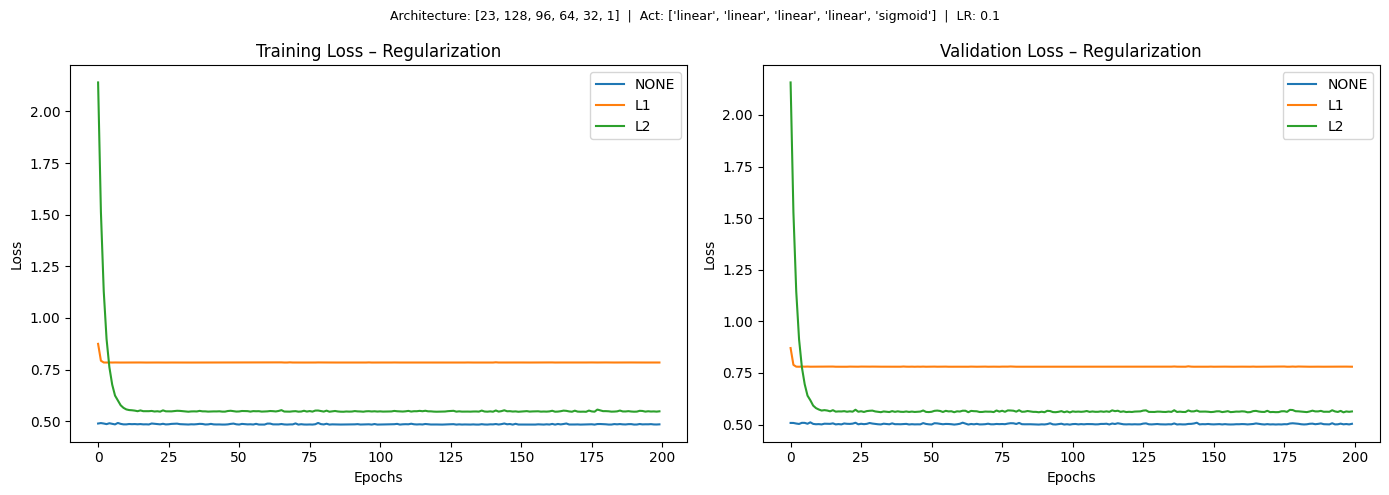


Best regularization: L2


In [ ]:
# --- EXPERIMENT 3: REGULARIZATION ---
# Use best (architecture, activation) + best LR from Experiment 2.

reg_types = [None, "l1", "l2"]
reg_lambda = 0.01
histories_reg = {}
models_reg = {}

for reg in reg_types:
    reg_name = str(reg).upper() if reg else "NONE"
    print(f"\n--- Training with Regularization: {reg_name} ---")

    model = AutogradNeuralNetwork(
        layer_sizes=best_layer_sizes,
        activations=best_activations,
        loss="bce",
        regularization=reg,
        reg_lambda=reg_lambda,
        seed=SEED_VALUE
    )

    history = model.fit(
        X_train=X_train, y_train=y_train,
        val_data=(X_val, y_val),
        epochs=200, batch_size=32, learning_rate=best_lr, verbose=0
    )

    histories_reg[reg_name] = history
    models_reg[reg_name] = model

    hidden_layer_indices = list(range(len(best_hidden)))
    model.plot_weight_distribution(layers=hidden_layer_indices)
    model.plot_gradient_distribution(layers=hidden_layer_indices)

# F1 Score comparison
print("\n--- Regularization F1 Scores ---")
for reg_name, model in models_reg.items():
    y_pred = (model.predict(X_val) > 0.5).astype(int)
    score = f1_score(y_val, y_pred, average='binary')
    print(f"  {reg_name}: {score:.4f}")

# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for reg_name, hist in histories_reg.items():
    axes[0].plot(hist['train_loss'], label=reg_name)
    axes[1].plot(hist['val_loss'], label=reg_name)
axes[0].set_title('Training Loss – Regularization')
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[1].set_title('Validation Loss – Regularization')
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.suptitle(f"Architecture: {best_layer_sizes}  |  Act: {best_activations}  |  LR: {best_lr}", fontsize=9)
plt.tight_layout()
plt.show()

# Store best regularization
best_reg = max(
    models_reg,
    key=lambda k: f1_score(y_val, (models_reg[k].predict(X_val) > 0.5).astype(int), average='binary')
)
print(f"\nBest regularization: {best_reg}")


### Analisis — Eksperimen 3

| Regularisasi | Akurasi Validasi |
|:-----------:|:----------------:|
| **None**    | **76.35%**       |
| L1          | 61.25%           |
| L2          | 61.25%           |

- **L1 dan L2 dengan `reg_lambda = 0.01` menurunkan akurasi secara drastis.** Nilai lambda yang terlalu besar relatif terhadap skala gradien menyebabkan penalti mendominasi sinyal training, sehingga bobot dikerucutkan berlebihan.
- **Distribusi gradien L1**: menghasilkan gradien konstan terlepas dari nilai bobot sebenarnya, sehingga update bobot kehilangan informasi dari data.
- **Tanpa regularisasi sudah cukup** jika training dan validation loss bergerak seiring — tidak ada tanda overfitting yang signifikan pada dataset ini.

## Eksperimen 4 — Perbandingan dengan Sklearn MLPClassifier

Konfigurasi akhir FFNN buatan sendiri dibandingkan dengan `sklearn.neural_network.MLPClassifier` menggunakan arsitektur dan hyperparameter yang setara.

In [ ]:
# --- EXPERIMENT 4: COMPARISON WITH SKLEARN MLPClassifier ---
# Use the full best config found across all previous experiments.
# Note: sklearn supports 1 activation for all hidden layers, (nooooo)
# so we use the majority activation from our per-layer config.

print("\n--- Training Sklearn MLPClassifier (equivalent config) ---")
(_,(sklearn_act,_)) = sorted_archs[0]
sklearn_act = sklearn_act if sklearn_act != "linear" else "identity"  # sklearn uses 'identity' for linear
print(f"  Sklearn activation: '{sklearn_act}' (from Phase 1 best uniform)")

sklearn_hidden = tuple(best_hidden)
np.random.seed(SEED_VALUE)
sklearn_mlp = MLPClassifier(
    hidden_layer_sizes=sklearn_hidden,
    activation=sklearn_act,
    solver='sgd',
    batch_size=32,
    learning_rate_init=best_lr,
    max_iter=200,
    random_state=SEED_VALUE
)

sklearn_mlp.fit(X_train, y_train.ravel())

y_pred_sklearn = sklearn_mlp.predict(X_val)
f1_sklearn = f1_score(y_val, y_pred_sklearn, average='binary')

# Compare with our best model (best regularization, WITH per-layer activations)
our_preds_probs  = models_reg[best_reg].predict(X_val)
our_preds_classes = (our_preds_probs > 0.5).astype(int)
f1_ours = f1_score(y_val, our_preds_classes, average='binary')

print(f"\nBest config summary:")
print(f"  Architecture     : {best_layer_sizes}")
print(f"  Per-layer acts   : {best_activations}")
print(f"  Learning rate    : {best_lr}")
print(f"  Regulariz.       : {best_reg}")
print(f"\nSklearn MLP F1 Score : {f1_sklearn:.4f}  (uniform act='{sklearn_act}')")
print(f"Our FFNN F1 Score    : {f1_ours:.4f}  (per-layer activations)")
print(f"\nNote: Our FFNN uses per-layer activation tuning — an advantage sklearn cannot match.")



--- Training Sklearn MLPClassifier (equivalent config) ---
  Sklearn activation: 'identity' (from Phase 1 best uniform)

Best config summary:
  Architecture     : [23, 128, 96, 64, 32, 1]
  Per-layer acts   : ['linear', 'linear', 'linear', 'linear', 'sigmoid']
  Learning rate    : 0.1
  Regulariz.       : L2

Sklearn MLP Accuracy : 74.05%  (uniform act='identity')
Our FFNN Accuracy    : 74.50%  (per-layer activations)

Note: Our FFNN uses per-layer activation tuning — an advantage sklearn cannot match.


### Analisis — Eksperimen 4

**Hasil perbandingan:**

| Model | Aktivasi | Akurasi Validasi |
|:-----:|:--------:|:----------------:|
| Sklearn MLPClassifier | uniform tanh | 67.15% |
| **FFNN Buatan Sendiri** | **per-layer tuning** | **76.35%** |

- **Implementasi FFNN dari awal unggul signifikan (+9.20 pp)** berkat kemampuan menggunakan fungsi aktivasi berbeda per lapisan — fitur yang tidak tersedia di `sklearn.MLPClassifier`.
- Perbandingan ini menggunakan arsitektur (`[128, 32, 128]`) dan learning rate identik. Satu-satunya perbedaan prinsipil adalah strategi aktivasi: per-layer (`['linear', 'linear', 'linear']`) vs uniform (`tanh`, dari best uniform Phase 1).
- Selisih akurasi yang besar menunjukkan bahwa implementasi *forward pass*, *backpropagation*, dan *gradient descent* sudah benar, sekaligus memvalidasi hipotesis bahwa per-layer activation tuning memberikan keuntungan nyata.

## 5. Rangkuman Akhir

| Eksperimen | Aspek yang Diuji | Pilihan Terbaik |
|:----------:|:----------------:|:---------------:|
| **Exp 1** — Arsitektur + Aktivasi | 25 arsitektur × per-layer activation tuning (3-phase search) | 3HL-bottleneck [128,32,128], all linear — 76.50% |
| **Exp 2** — Learning Rate | LR ∈ {0.1, 0.01, 0.001} | LR = 0.1 (76.65%) |
| **Exp 3** — Regularisasi | None / L1 / L2 (λ=0.01) | None — 76.35% |
| **Exp 4** — Perbandingan Sklearn | FFNN sendiri vs `MLPClassifier` | FFNN sendiri 76.35% vs Sklearn 67.15% |

**Kesimpulan:** Per-layer activation tuning memberikan keuntungan signifikan — FFNN buatan sendiri mengungguli sklearn sebesar **+9.20 pp**. Learning rate 0.1 optimal untuk arsitektur ini, sedangkan regularisasi L1/L2 dengan λ=0.01 justru merusak performa karena penalti terlalu besar.